In [1]:
import torch
from torch import nn
from models import ClsModel
from torch.utils import data
import metrics
from config import SEED, TRAIN_BS, VAL_BS, COLORED_PROPORTION, CLS_EPOCHS
import train_utils
import plot_utils
import matplotlib.pyplot as plt

In [2]:
plt.style.use('default')

In [3]:
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "mps"

In [4]:
metrics_calculator = metrics.MetricsCalculator(num_classes=10)
metrics_calculator.reset()

In [5]:
train_dataset = torch.load("./data/train_dataset.pt", weights_only=False)
val_dataset = torch.load("./data/val_dataset.pt", weights_only=False)
clean_val_dataset = torch.load("./data/clean_val_dataset.pt", weights_only=False)
fully_colored_val_dataset = torch.load("./data/fully_colored_val_dataset.pt", weights_only=False)
colors_flipped_val_dataset = torch.load("./data/colors_flipped_val_dataset.pt", weights_only=False)

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 321.39it/s]


Epoch 1/3 - Train Loss: 0.0107, Val Loss: 0.0025, Accuracy: 0.9893, Precision: 0.9893, Recall: 0.9893, F1 Score: 0.9893, AUPRC: 0.9968, AUROC: 0.9985


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 325.28it/s]


Epoch 2/3 - Train Loss: 0.0019, Val Loss: 0.0013, Accuracy: 0.9930, Precision: 0.9930, Recall: 0.9930, F1 Score: 0.9930, AUPRC: 0.9972, AUROC: 0.9986


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 233.76it/s]

Epoch 3/3 - Train Loss: 0.0011, Val Loss: 0.0009, Accuracy: 0.9937, Precision: 0.9937, Recall: 0.9937, F1 Score: 0.9937, AUPRC: 0.9983, AUROC: 0.9993


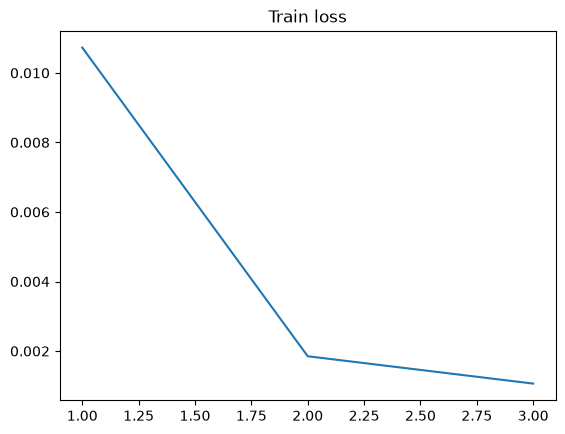

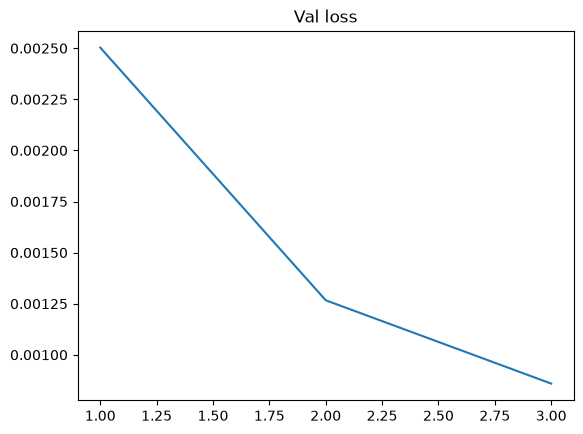

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 324.02it/s]

Performance on clean validation set:
Clean Val Loss: 0.0152, Accuracy: 0.8583, Precision: 0.8583, Recall: 0.8583, F1 Score: 0.8583, AUPRC: 0.9122, AUROC: 0.9766
Performance on fully colored validation set:
Fully Colored Val Loss: 0.0002, Accuracy: 0.9997, Precision: 0.9997, Recall: 0.9997, F1 Score: 0.9997, AUPRC: 0.9998, AUROC: 1.0000
Performance on validation set with colors flipped:
Colors flipped Val Loss: 0.1528, Accuracy: 0.3306, Precision: 0.3306, Recall: 0.3306, F1 Score: 0.3306, AUPRC: 0.3326, AUROC: 0.6184


In [6]:
train_dataloader = data.DataLoader(train_dataset, batch_size=TRAIN_BS, shuffle=True)
val_dataloader = data.DataLoader(val_dataset, batch_size=VAL_BS)
clean_val_dataloader = data.DataLoader(clean_val_dataset, batch_size=VAL_BS)
fully_colored_val_dataloader = data.DataLoader(fully_colored_val_dataset, batch_size=VAL_BS)
colors_flipped_val_dataloader = data.DataLoader(colors_flipped_val_dataset, batch_size=VAL_BS)

model = ClsModel()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Train the model
train_losses, val_losses = train_utils.cls_train(model, train_dataloader, val_dataloader, criterion, optimizer, metrics_calculator, device=device, epochs=CLS_EPOCHS)

# Plot results
plot_utils.plot_loss(train_losses, "Train loss")
plot_utils.plot_loss(val_losses, "Val loss")

# Evaluate the model on clean validation dataset
clean_val_loss = train_utils.cls_evaluate(model, clean_val_dataloader, criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
fully_colored_val_loss = train_utils.cls_evaluate(model, fully_colored_val_dataloader, criterion, metrics_calculator, device)
fully_colored_val_accuracy, fully_colored_val_precision, fully_colored_val_recall, fully_colored_val_f1_score, fully_colored_val_auprc, fully_colored_val_auroc = metrics_calculator.compute_all()

colors_flipped_val_loss = train_utils.cls_evaluate(model, colors_flipped_val_dataloader, criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss:.4f}, Accuracy: {clean_val_accuracy:.4f}, Precision: {clean_val_precision:.4f}, Recall: {clean_val_recall:.4f}, F1 Score: {clean_val_f1_score:.4f}, AUPRC: {clean_val_auprc:.4f}, AUROC: {clean_val_auroc:.4f}")
print("Performance on fully colored validation set:")
print(f"Fully Colored Val Loss: {fully_colored_val_loss:.4f}, Accuracy: {fully_colored_val_accuracy:.4f}, Precision: {fully_colored_val_precision:.4f}, Recall: {fully_colored_val_recall:.4f}, F1 Score: {fully_colored_val_f1_score:.4f}, AUPRC: {fully_colored_val_auprc:.4f}, AUROC: {fully_colored_val_auroc:.4f}")

print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss:.4f}, Accuracy: {colors_flipped_val_accuracy:.4f}, Precision: {colors_flipped_val_precision:.4f}, Recall: {colors_flipped_val_recall:.4f}, F1 Score: {colors_flipped_val_f1_score:.4f}, AUPRC: {colors_flipped_val_auprc:.4f}, AUROC: {colors_flipped_val_auroc:.4f}")


In [7]:
torch.save(model.state_dict(), f"./weights/cls_model_{COLORED_PROPORTION}.pt")